In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


In [42]:
# Load the .npz file
data = np.load('/home/dataopske/Desktop/jav/data/raw/worldmove/worldmove_trajectories.npz', allow_pickle=True)

# See what's inside (keys like 'lon', 'lat', 'time', 'agent_id', etc.)
print("Keys in the file:", data.files)

# Example: Print shapes of arrays (adjust keys based on output)
for key in data.files:
    print(f"{key}: shape={data[key].shape}, dtype={data[key].dtype}")

Keys in the file: ['grid', 'poi', 'pop', 'traj']
grid: shape=(), dtype=object
poi: shape=(30, 48, 34), dtype=float32
pop: shape=(30, 48), dtype=float64
traj: shape=(104538, 48), dtype=int64


| Key    | Shape          | Meaning (most likely)                                                                                                         |
| ------ | -------------- | ----------------------------------------------------------------------------------------------------------------------------- |
| `grid` | `()` (object)  | Contains metadata about the spatial grid — e.g., lat/lon coordinates of each grid cell. You’ll want to inspect this directly. |
| `poi`  | `(30, 48, 34)` | Likely a **Point of Interest (POI)** tensor — 30 “regions” × 48 “features” × 34 “categories/features per region.”             |
| `pop`  | `(30, 48)`     | Population density or population count per grid cell (matches first two dims of `poi`).                                       |
| `traj` | `(104538, 48)` | Trajectory data — possibly 104,538 trajectories each sampled across 48 timesteps.                                             |


In [27]:
grid = data['grid']
poi = data['poi']      # (30, 48, 34) - 30 regions, 48 timesteps, 34 POI features
pop = data['pop']      # (30, 48) - 30 regions, 48 timesteps
traj = data['traj']    # (104538, 48) - 104538 trajectories, 48 timesteps

print(f"Grid data type: {type(grid)}")
if hasattr(grid, 'item'):
    grid_dict = grid.item()
    print(f"Grid contents: {grid_dict}")

Grid data type: <class 'numpy.ndarray'>
Grid contents: {'0': [36.668782324384324, -1.165733963250385], '1': [36.67543672701437, -1.1679757740710577], '2': [36.68926997604133, -1.165172667714417], '3': [36.69770436432493, -1.167777360555599], '4': [36.709963691227266, -1.1615857827542182], '5': [36.71899313338355, -1.161481556397721], '6': [36.72531673525535, -1.1672003957773704], '7': [36.730702889319886, -1.1698347274192804], '8': [36.73869098563992, -1.1683481907164726], '9': [36.754613041189586, -1.1670429895819314], '10': [36.75835046608578, -1.1671175458900143], '11': [36.77161497422534, -1.163280674687849], '12': [36.77604415578723, -1.1634632464825454], '13': [36.783381624377306, -1.1676473713181592], '14': [36.79730389150035, -1.164531607850986], '15': [36.808529466478085, -1.1678558030107073], '16': [36.81124856946388, -1.1671393545949629], '17': [36.82356332533454, -1.162910061646793], '18': [36.82746870497967, -1.1686338328261212], '19': [36.841024298354206, -1.1683981032699

In [28]:
print("TRAJECTORY DATA ANALYSIS")
print("="*60)
print(f"Number of trajectories: {traj.shape[0]:,}")
print(f"Sequence length: {traj.shape[1]}")
print(f"Min location ID: {traj.min()}")
print(f"Max location ID: {traj.max()}")
print(f"Number of unique locations: {len(np.unique(traj))}")
print(f"\nSample trajectory (first 10 steps):\n{traj[0, :10]}")

TRAJECTORY DATA ANALYSIS
Number of trajectories: 104,538
Sequence length: 48
Min location ID: 0
Max location ID: 1439
Number of unique locations: 1440

Sample trajectory (first 10 steps):
[265 265 265 265 265 265 265 265 265 265]


In [29]:
# Flatten all trajectories to analyze location frequency
all_locations = traj.flatten()
location_counts = Counter(all_locations)
locations, counts = zip(*sorted(location_counts.items()))

print(f"Total location visits: {len(all_locations):,}")
print(f"Unique locations visited: {len(location_counts)}")
print(f"\nTop 10 most visited locations:")
for loc, count in sorted(location_counts.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  Location {loc}: {count:,} visits ({count/len(all_locations)*100:.2f}%)")

Total location visits: 5,017,824
Unique locations visited: 1440

Top 10 most visited locations:
  Location 456: 53,133 visits (1.06%)
  Location 504: 48,178 visits (0.96%)
  Location 455: 48,150 visits (0.96%)
  Location 548: 46,639 visits (0.93%)
  Location 502: 43,978 visits (0.88%)
  Location 503: 42,812 visits (0.85%)
  Location 408: 40,717 visits (0.81%)
  Location 781: 40,078 visits (0.80%)
  Location 648: 39,210 visits (0.78%)
  Location 549: 38,757 visits (0.77%)


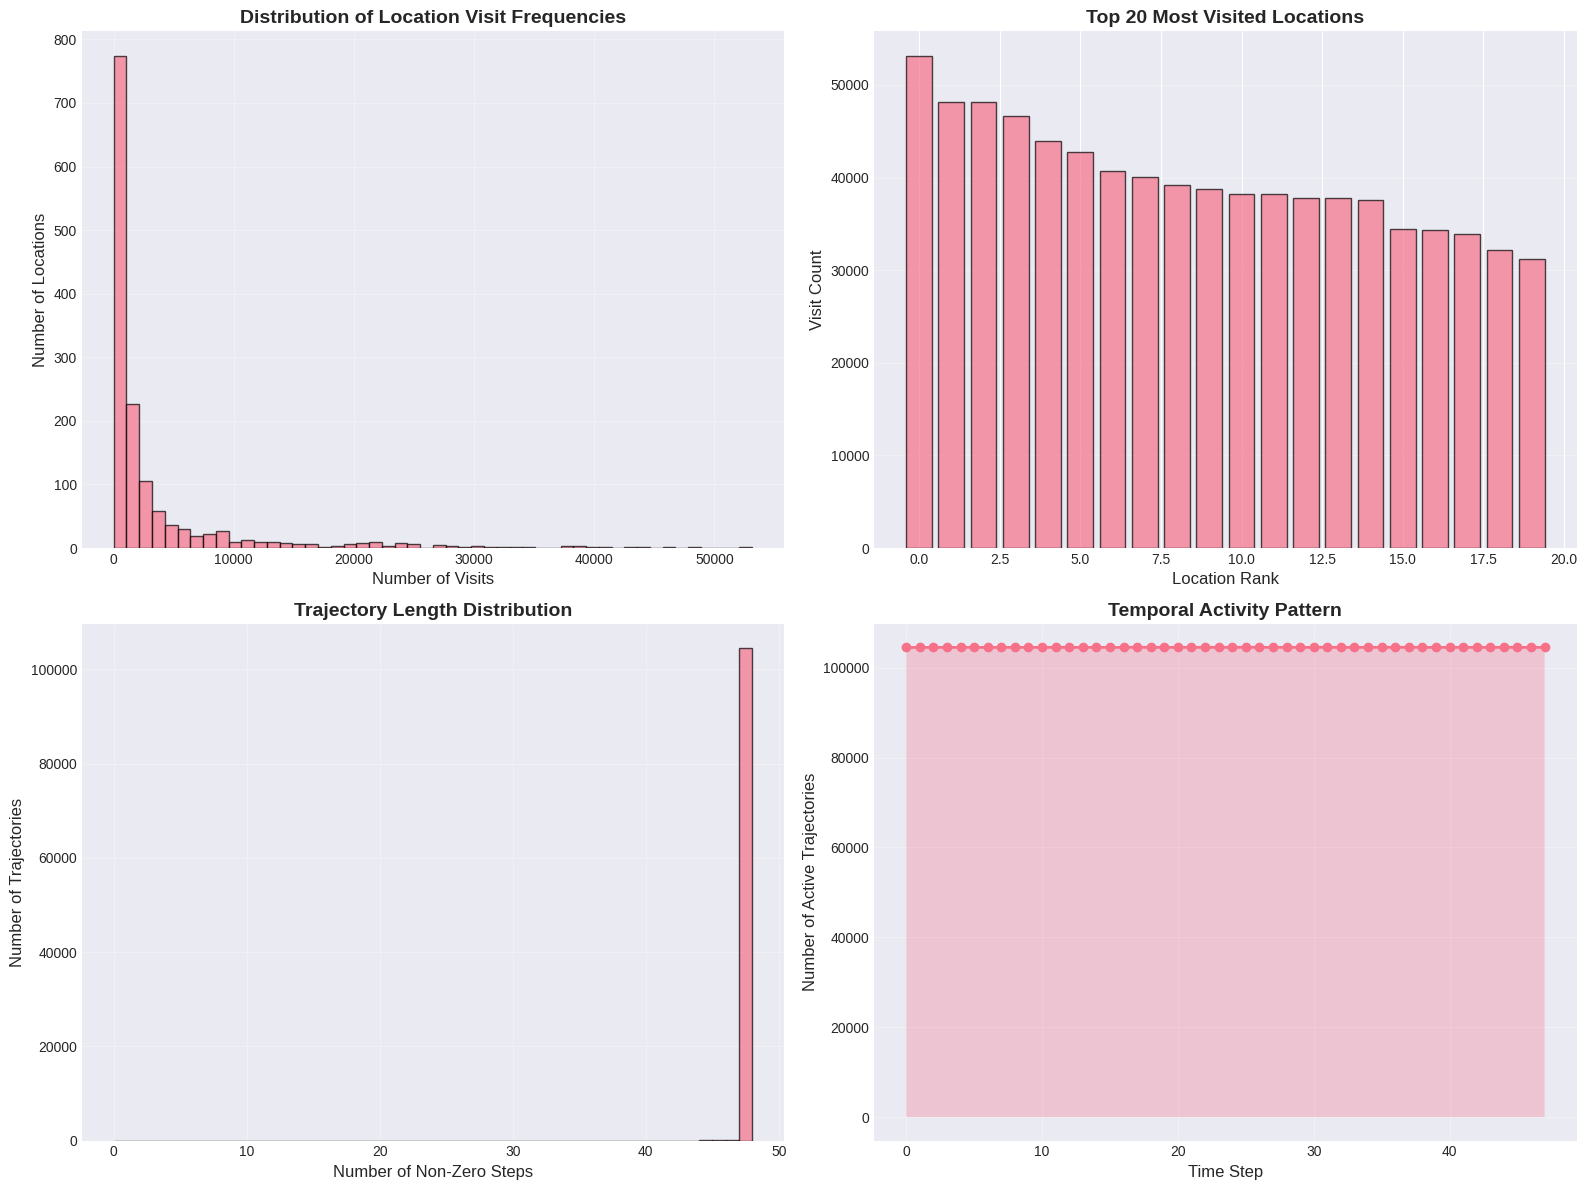

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Location frequency histogram
ax = axes[0, 0]
ax.hist(counts, bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel('Number of Visits', fontsize=12)
ax.set_ylabel('Number of Locations', fontsize=12)
ax.set_title('Distribution of Location Visit Frequencies', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Top 20 locations bar plot
ax = axes[0, 1]
top_20 = sorted(location_counts.items(), key=lambda x: x[1], reverse=True)[:20]
locs, cnts = zip(*top_20)
ax.bar(range(len(locs)), cnts, alpha=0.7, edgecolor='black')
ax.set_xlabel('Location Rank', fontsize=12)
ax.set_ylabel('Visit Count', fontsize=12)
ax.set_title('Top 20 Most Visited Locations', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Trajectory length distribution (non-zero entries per trajectory)
ax = axes[1, 0]
non_zero_counts = np.sum(traj != 0, axis=1)
ax.hist(non_zero_counts, bins=48, edgecolor='black', alpha=0.7)
ax.set_xlabel('Number of Non-Zero Steps', fontsize=12)
ax.set_ylabel('Number of Trajectories', fontsize=12)
ax.set_title('Trajectory Length Distribution', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Temporal activity pattern
ax = axes[1, 1]
temporal_activity = np.sum(traj != 0, axis=0)
ax.plot(range(48), temporal_activity, marker='o', linewidth=2, markersize=6)
ax.fill_between(range(48), temporal_activity, alpha=0.3)
ax.set_xlabel('Time Step', fontsize=12)
ax.set_ylabel('Number of Active Trajectories', fontsize=12)
ax.set_title('Temporal Activity Pattern', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('trajectory_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
# Cell 7: Population Data Analysis
# ============================================================================
print("\nPOPULATION DATA ANALYSIS")
print("="*60)
print(f"Population shape: {pop.shape} (regions × timesteps)")
print(f"Min population: {pop.min():.2f}")
print(f"Max population: {pop.max():.2f}")
print(f"Mean population: {pop.mean():.2f}")
print(f"Std population: {pop.std():.2f}")


POPULATION DATA ANALYSIS
Population shape: (30, 48) (regions × timesteps)
Min population: 23.11
Max population: 280940.47
Mean population: 14413.04
Std population: 31914.89


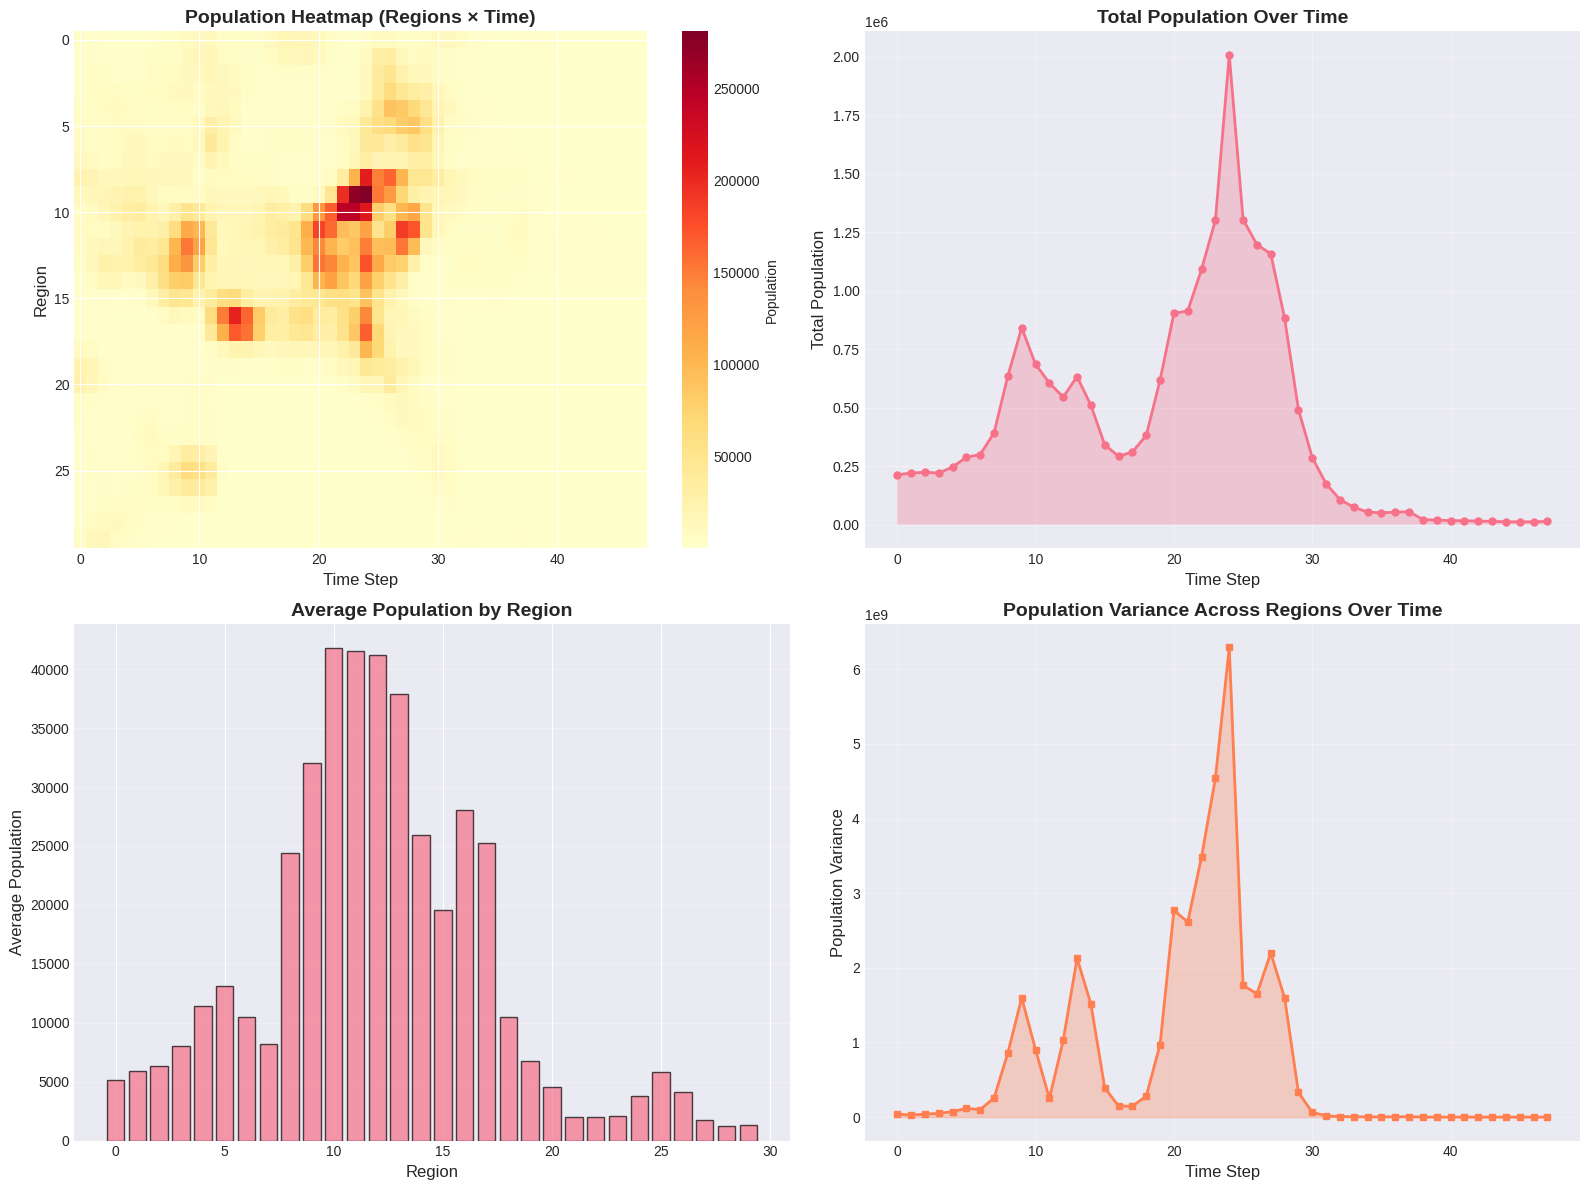

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Population heatmap
ax = axes[0, 0]
im = ax.imshow(pop, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax.set_xlabel('Time Step', fontsize=12)
ax.set_ylabel('Region', fontsize=12)
ax.set_title('Population Heatmap (Regions × Time)', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax, label='Population')

# Population over time (aggregated)
ax = axes[0, 1]
total_pop_time = pop.sum(axis=0)
ax.plot(range(48), total_pop_time, linewidth=2, marker='o', markersize=5)
ax.fill_between(range(48), total_pop_time, alpha=0.3)
ax.set_xlabel('Time Step', fontsize=12)
ax.set_ylabel('Total Population', fontsize=12)
ax.set_title('Total Population Over Time', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Population by region (averaged over time)
ax = axes[1, 0]
avg_pop_region = pop.mean(axis=1)
ax.bar(range(30), avg_pop_region, alpha=0.7, edgecolor='black')
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Average Population', fontsize=12)
ax.set_title('Average Population by Region', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Population variance over time
ax = axes[1, 1]
pop_variance = pop.var(axis=0)
ax.plot(range(48), pop_variance, linewidth=2, marker='s', markersize=5, color='coral')
ax.fill_between(range(48), pop_variance, alpha=0.3, color='coral')
ax.set_xlabel('Time Step', fontsize=12)
ax.set_ylabel('Population Variance', fontsize=12)
ax.set_title('Population Variance Across Regions Over Time', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('population_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [33]:
# Cell 9: POI (Points of Interest) Analysis
# ============================================================================
print("\nPOI DATA ANALYSIS")
print("="*60)
print(f"POI shape: {poi.shape} (regions × timesteps × features)")
print(f"Number of POI features: {poi.shape[2]}")
print(f"Min POI value: {poi.min():.4f}")
print(f"Max POI value: {poi.max():.4f}")
print(f"Mean POI value: {poi.mean():.4f}")
print(f"Std POI value: {poi.std():.4f}")



POI DATA ANALYSIS
POI shape: (30, 48, 34) (regions × timesteps × features)
Number of POI features: 34
Min POI value: 0.0000
Max POI value: 0.0000
Mean POI value: 0.0000
Std POI value: 0.0000


/home/dataopske/Desktop/jav/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


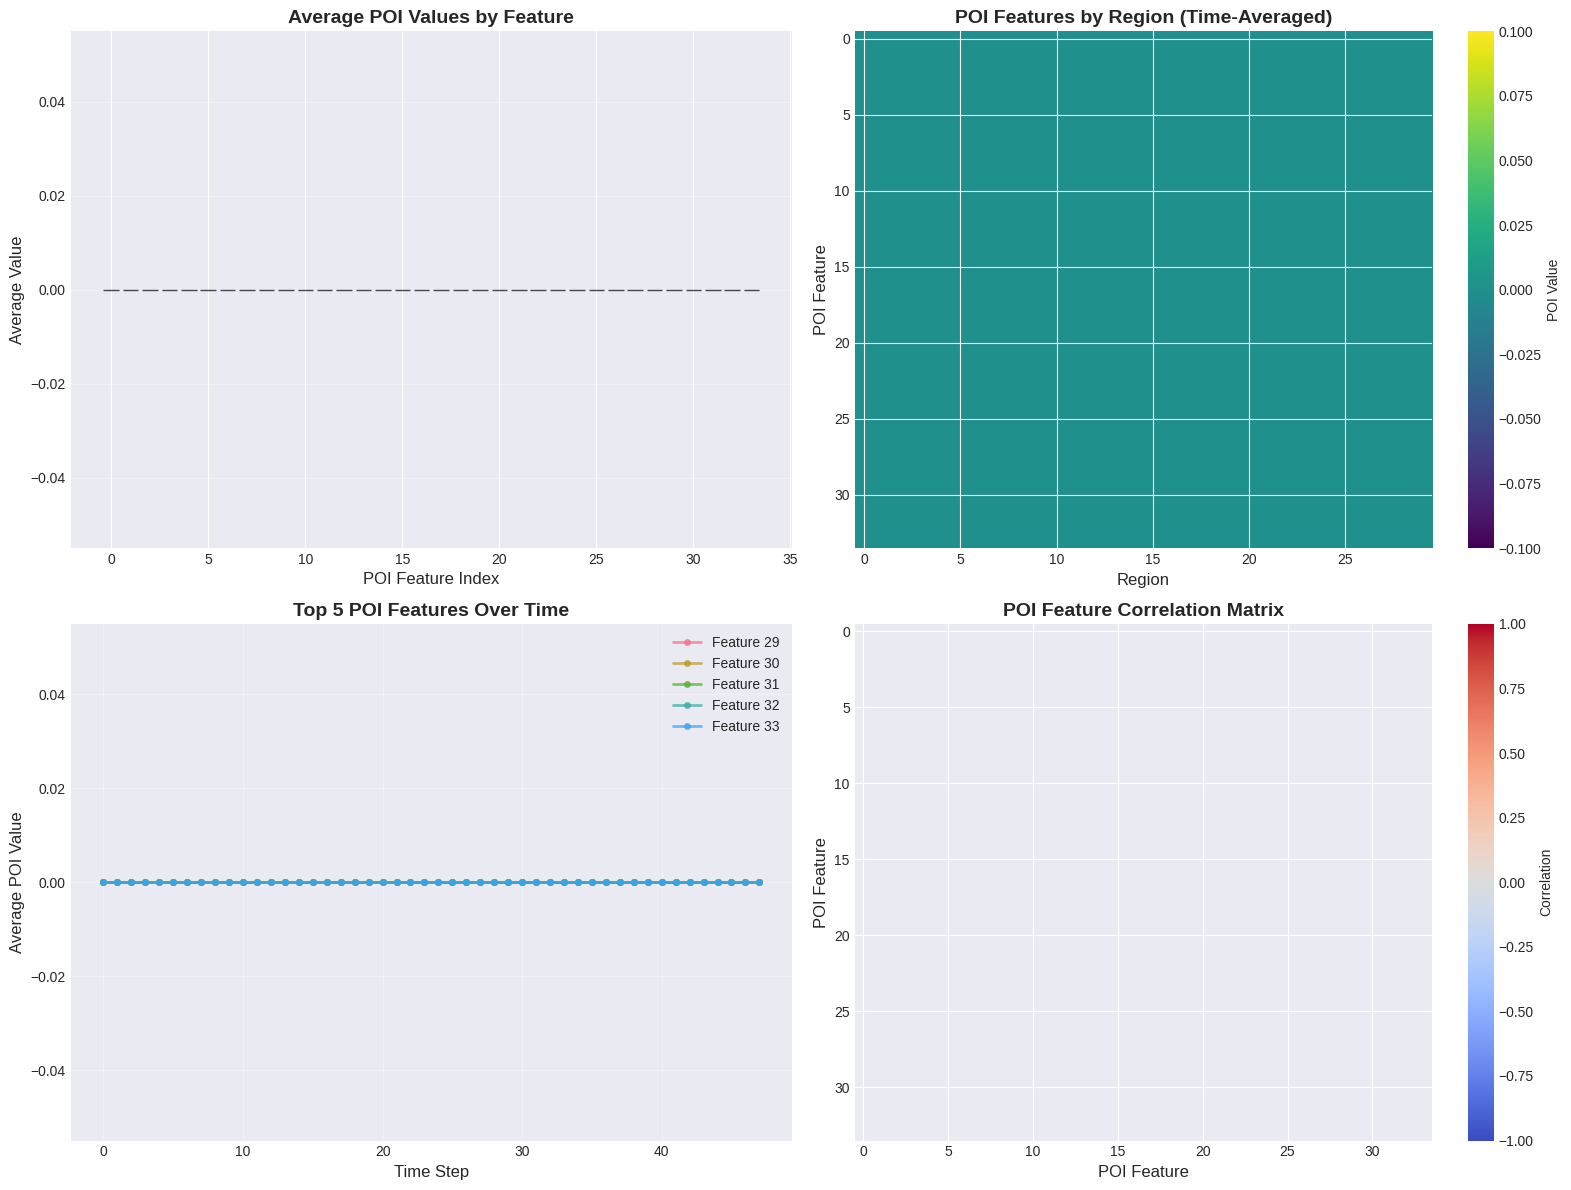

In [34]:
# Cell 10: Visualize POI Features
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Average POI values per feature
ax = axes[0, 0]
avg_poi_per_feature = poi.mean(axis=(0, 1))
ax.bar(range(34), avg_poi_per_feature, alpha=0.7, edgecolor='black')
ax.set_xlabel('POI Feature Index', fontsize=12)
ax.set_ylabel('Average Value', fontsize=12)
ax.set_title('Average POI Values by Feature', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# POI feature heatmap (averaged over time)
ax = axes[0, 1]
poi_region_avg = poi.mean(axis=1)  # Average over time
im = ax.imshow(poi_region_avg.T, aspect='auto', cmap='viridis', interpolation='nearest')
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('POI Feature', fontsize=12)
ax.set_title('POI Features by Region (Time-Averaged)', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax, label='POI Value')

# Temporal evolution of top 5 POI features
ax = axes[1, 0]
top_5_features = np.argsort(avg_poi_per_feature)[-5:]
for feat_idx in top_5_features:
    temporal_avg = poi[:, :, feat_idx].mean(axis=0)
    ax.plot(range(48), temporal_avg, marker='o', linewidth=2, markersize=4, 
            label=f'Feature {feat_idx}', alpha=0.7)
ax.set_xlabel('Time Step', fontsize=12)
ax.set_ylabel('Average POI Value', fontsize=12)
ax.set_title('Top 5 POI Features Over Time', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# POI feature correlation (time and region averaged)
ax = axes[1, 1]
poi_flat = poi.reshape(-1, 34)
poi_corr = np.corrcoef(poi_flat.T)
im = ax.imshow(poi_corr, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
ax.set_xlabel('POI Feature', fontsize=12)
ax.set_ylabel('POI Feature', fontsize=12)
ax.set_title('POI Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax, label='Correlation')

plt.tight_layout()
plt.savefig('poi_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [35]:
# Cell 11: Transition Matrix Analysis
# ============================================================================
print("\nTRAJECTORY TRANSITION ANALYSIS")
print("="*60)

# Calculate transition matrix (from location i to location j)
n_locations = traj.max() + 1
transition_matrix = np.zeros((n_locations, n_locations))

for trajectory in traj:
    for i in range(len(trajectory) - 1):
        from_loc = trajectory[i]
        to_loc = trajectory[i + 1]
        if from_loc >= 0 and to_loc >= 0:  # Ignore padding
            transition_matrix[from_loc, to_loc] += 1

# Normalize to get transition probabilities
row_sums = transition_matrix.sum(axis=1, keepdims=True)
transition_prob = np.divide(transition_matrix, row_sums, 
                            where=row_sums != 0, out=np.zeros_like(transition_matrix))

print(f"Transition matrix shape: {transition_matrix.shape}")
print(f"Non-zero transitions: {np.count_nonzero(transition_matrix):,}")
print(f"Sparsity: {(1 - np.count_nonzero(transition_matrix) / transition_matrix.size) * 100:.2f}%")



TRAJECTORY TRANSITION ANALYSIS
Transition matrix shape: (1440, 1440)
Non-zero transitions: 119,196
Sparsity: 94.25%


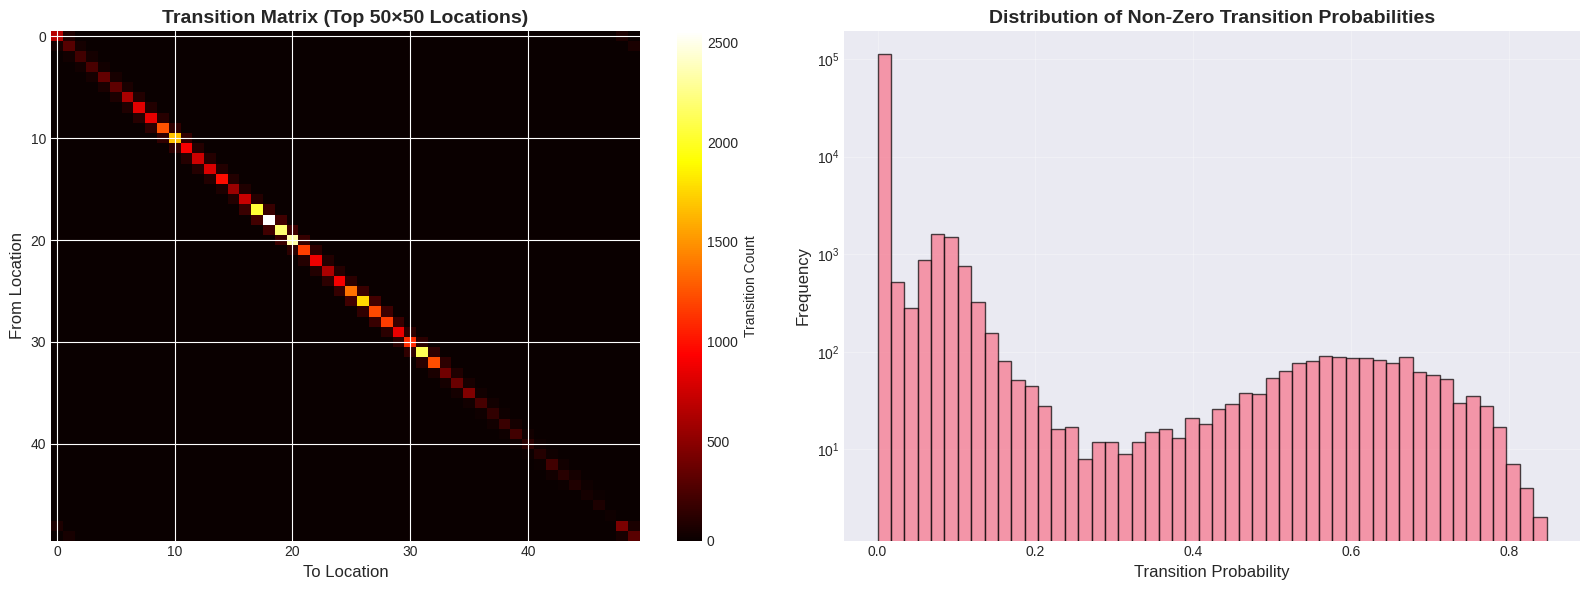

In [36]:
# Cell 12: Visualize Transition Patterns
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sample of transition matrix (top 50x50 locations)
ax = axes[0]
sample_size = min(50, n_locations)
im = ax.imshow(transition_matrix[:sample_size, :sample_size], 
               cmap='hot', interpolation='nearest', aspect='auto')
ax.set_xlabel('To Location', fontsize=12)
ax.set_ylabel('From Location', fontsize=12)
ax.set_title(f'Transition Matrix (Top {sample_size}×{sample_size} Locations)', 
             fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax, label='Transition Count')

# Transition probability distribution
ax = axes[1]
non_zero_probs = transition_prob[transition_prob > 0]
ax.hist(non_zero_probs, bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel('Transition Probability', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Non-Zero Transition Probabilities', 
             fontsize=14, fontweight='bold')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('transition_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [37]:
# Cell 13: LSTM Preparation Summary
# ============================================================================
print("\n" + "="*60)
print("LSTM TRAINING PREPARATION SUMMARY")
print("="*60)
print("\n📊 DATA CHARACTERISTICS:")
print(f"  • Input sequences: {traj.shape[0]:,} trajectories")
print(f"  • Sequence length: {traj.shape[1]} timesteps")
print(f"  • Vocabulary size: {n_locations} unique locations")
print(f"  • Auxiliary features:")
print(f"    - POI features: {poi.shape[2]} features per (region, timestep)")
print(f"    - Population: 1 feature per (region, timestep)")

print("\n🎯 LSTM ARCHITECTURE RECOMMENDATIONS:")
print(f"  • Input dimension: {n_locations} (one-hot encoded locations)")
print(f"  • Or embedding dimension: 50-200 (learned embeddings)")
print(f"  • Sequence length: {traj.shape[1]}")
print(f"  • Additional context features: {poi.shape[2] + 1} (POI + population)")
print(f"  • Output dimension: {n_locations} (next location prediction)")

print("\n⚙️ PREPROCESSING STEPS NEEDED:")
print("  1. Handle padding/zero values in trajectories")
print("  2. Create train/val/test splits (e.g., 80/10/10)")
print("  3. Normalize POI and population features")
print("  4. Create location embeddings or one-hot encodings")
print("  5. Align POI/population data with trajectory timestamps")
print("  6. Consider sequence masking for variable lengths")

print("\n💡 KEY INSIGHTS:")
print(f"  • Transition sparsity: {(1 - np.count_nonzero(transition_matrix) / transition_matrix.size) * 100:.1f}%")
print(f"  • Avg trajectory activity: {np.mean(np.sum(traj != 0, axis=1)):.1f} non-zero steps")
print(f"  • Location visit imbalance: Top location has {max(counts):,} visits")

print("\n✅ Dataset ready for LSTM training!")
print("="*60)


LSTM TRAINING PREPARATION SUMMARY

📊 DATA CHARACTERISTICS:
  • Input sequences: 104,538 trajectories
  • Sequence length: 48 timesteps
  • Vocabulary size: 1440 unique locations
  • Auxiliary features:
    - POI features: 34 features per (region, timestep)
    - Population: 1 feature per (region, timestep)

🎯 LSTM ARCHITECTURE RECOMMENDATIONS:
  • Input dimension: 1440 (one-hot encoded locations)
  • Or embedding dimension: 50-200 (learned embeddings)
  • Sequence length: 48
  • Additional context features: 35 (POI + population)
  • Output dimension: 1440 (next location prediction)

⚙️ PREPROCESSING STEPS NEEDED:
  1. Handle padding/zero values in trajectories
  2. Create train/val/test splits (e.g., 80/10/10)
  3. Normalize POI and population features
  4. Create location embeddings or one-hot encodings
  5. Align POI/population data with trajectory timestamps
  6. Consider sequence masking for variable lengths

💡 KEY INSIGHTS:
  • Transition sparsity: 94.3%
  • Avg trajectory activi

In [43]:
# Load the separate POI file
poi_separate = np.load('/home/dataopske/Desktop/jav/data/raw/worldmove/grid-cell_POI.npy', 
                       allow_pickle=True)

print(f"\nSeparate POI file shape: {poi_separate.shape}")
print(f"Separate POI file dtype: {poi_separate.dtype}")
print(f"NPZ POI shape: {poi.shape}")
print(f"NPZ POI dtype: {poi.dtype}")

# Check if they're identical
print(f"\n🔍 Comparing POI sources:")
print(f"  • Shapes match: {poi_separate.shape == poi.shape}")
print(f"  • Are arrays identical: {np.array_equal(poi_separate, poi)}")
if not np.array_equal(poi_separate, poi):
    print(f"  • Max absolute difference: {np.max(np.abs(poi_separate - poi)):.6f}")
    print(f"  • Mean absolute difference: {np.mean(np.abs(poi_separate - poi)):.6f}")
else:
    print("  ✅ Arrays are identical - same data source!")


Separate POI file shape: (30, 48, 34)
Separate POI file dtype: float32
NPZ POI shape: (30, 48, 34)
NPZ POI dtype: float32

🔍 Comparing POI sources:
  • Shapes match: True
  • Are arrays identical: True
  ✅ Arrays are identical - same data source!


In [44]:
print("\n" + "="*60)
print("POI FEATURE IDENTIFICATION")
print("="*60)

# Check if there's metadata in the file
print("\n📋 Checking for POI category descriptions...")
print(f"POI file type: {type(poi_separate)}")

# Common POI categories in mobility datasets (likely candidates)
common_poi_categories = [
    'Restaurant/Cafe', 'Fast Food', 'Bar/Pub',
    'Grocery Store', 'Shopping Mall', 'Retail Store',
    'Bank/ATM', 'Post Office',
    'Hospital', 'Clinic', 'Pharmacy',
    'School', 'University', 'Library',
    'Park', 'Sports Facility', 'Gym',
    'Cinema', 'Theater', 'Museum',
    'Hotel', 'Airport', 'Train Station',
    'Bus Stop', 'Subway Station',
    'Office Building', 'Government Building',
    'Residential', 'Industrial',
    'Gas Station', 'Parking',
    'Religious Site', 'Cemetery',
    'Beach', 'Other'
]

print(f"\n💡 Your data has {poi.shape[2]} POI features")
print(f"Common POI categories in mobility datasets: {len(common_poi_categories)}")
print("\nLikely POI categories (34 features):")
for i in range(min(34, len(common_poi_categories))):
    print(f"  Feature {i:2d}: {common_poi_categories[i] if i < len(common_poi_categories) else 'Unknown'}")


POI FEATURE IDENTIFICATION

📋 Checking for POI category descriptions...
POI file type: <class 'numpy.ndarray'>

💡 Your data has 34 POI features
Common POI categories in mobility datasets: 35

Likely POI categories (34 features):
  Feature  0: Restaurant/Cafe
  Feature  1: Fast Food
  Feature  2: Bar/Pub
  Feature  3: Grocery Store
  Feature  4: Shopping Mall
  Feature  5: Retail Store
  Feature  6: Bank/ATM
  Feature  7: Post Office
  Feature  8: Hospital
  Feature  9: Clinic
  Feature 10: Pharmacy
  Feature 11: School
  Feature 12: University
  Feature 13: Library
  Feature 14: Park
  Feature 15: Sports Facility
  Feature 16: Gym
  Feature 17: Cinema
  Feature 18: Theater
  Feature 19: Museum
  Feature 20: Hotel
  Feature 21: Airport
  Feature 22: Train Station
  Feature 23: Bus Stop
  Feature 24: Subway Station
  Feature 25: Office Building
  Feature 26: Government Building
  Feature 27: Residential
  Feature 28: Industrial
  Feature 29: Gas Station
  Feature 30: Parking
  Feature 3

In [45]:
print("\n" + "="*60)
print("POI FEATURE STATISTICS")
print("="*60)

# Analyze each POI feature
poi_stats = []
for feat_idx in range(poi.shape[2]):
    feat_data = poi[:, :, feat_idx]
    poi_stats.append({
        'Feature': feat_idx,
        'Mean': feat_data.mean(),
        'Std': feat_data.std(),
        'Min': feat_data.min(),
        'Max': feat_data.max(),
        'Non-zero %': (feat_data != 0).mean() * 100
    })

poi_df = pd.DataFrame(poi_stats)
print("\n📊 POI Feature Statistics:")
print(poi_df.to_string(index=False))

# Identify most important features
print("\n🎯 Top 10 Most Active POI Features (by mean value):")
top_features = poi_df.nlargest(10, 'Mean')
for idx, row in top_features.iterrows():
    print(f"  Feature {row['Feature']:2.0f}: Mean={row['Mean']:.4f}, "
          f"Non-zero={row['Non-zero %']:.1f}%")


POI FEATURE STATISTICS

📊 POI Feature Statistics:
 Feature  Mean  Std  Min  Max  Non-zero %
       0   0.0  0.0  0.0  0.0         0.0
       1   0.0  0.0  0.0  0.0         0.0
       2   0.0  0.0  0.0  0.0         0.0
       3   0.0  0.0  0.0  0.0         0.0
       4   0.0  0.0  0.0  0.0         0.0
       5   0.0  0.0  0.0  0.0         0.0
       6   0.0  0.0  0.0  0.0         0.0
       7   0.0  0.0  0.0  0.0         0.0
       8   0.0  0.0  0.0  0.0         0.0
       9   0.0  0.0  0.0  0.0         0.0
      10   0.0  0.0  0.0  0.0         0.0
      11   0.0  0.0  0.0  0.0         0.0
      12   0.0  0.0  0.0  0.0         0.0
      13   0.0  0.0  0.0  0.0         0.0
      14   0.0  0.0  0.0  0.0         0.0
      15   0.0  0.0  0.0  0.0         0.0
      16   0.0  0.0  0.0  0.0         0.0
      17   0.0  0.0  0.0  0.0         0.0
      18   0.0  0.0  0.0  0.0         0.0
      19   0.0  0.0  0.0  0.0         0.0
      20   0.0  0.0  0.0  0.0         0.0
      21   0.0  0.0  0.0 

/tmp/ipykernel_8980/628987609.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=top_10_idx, patch_artist=True)


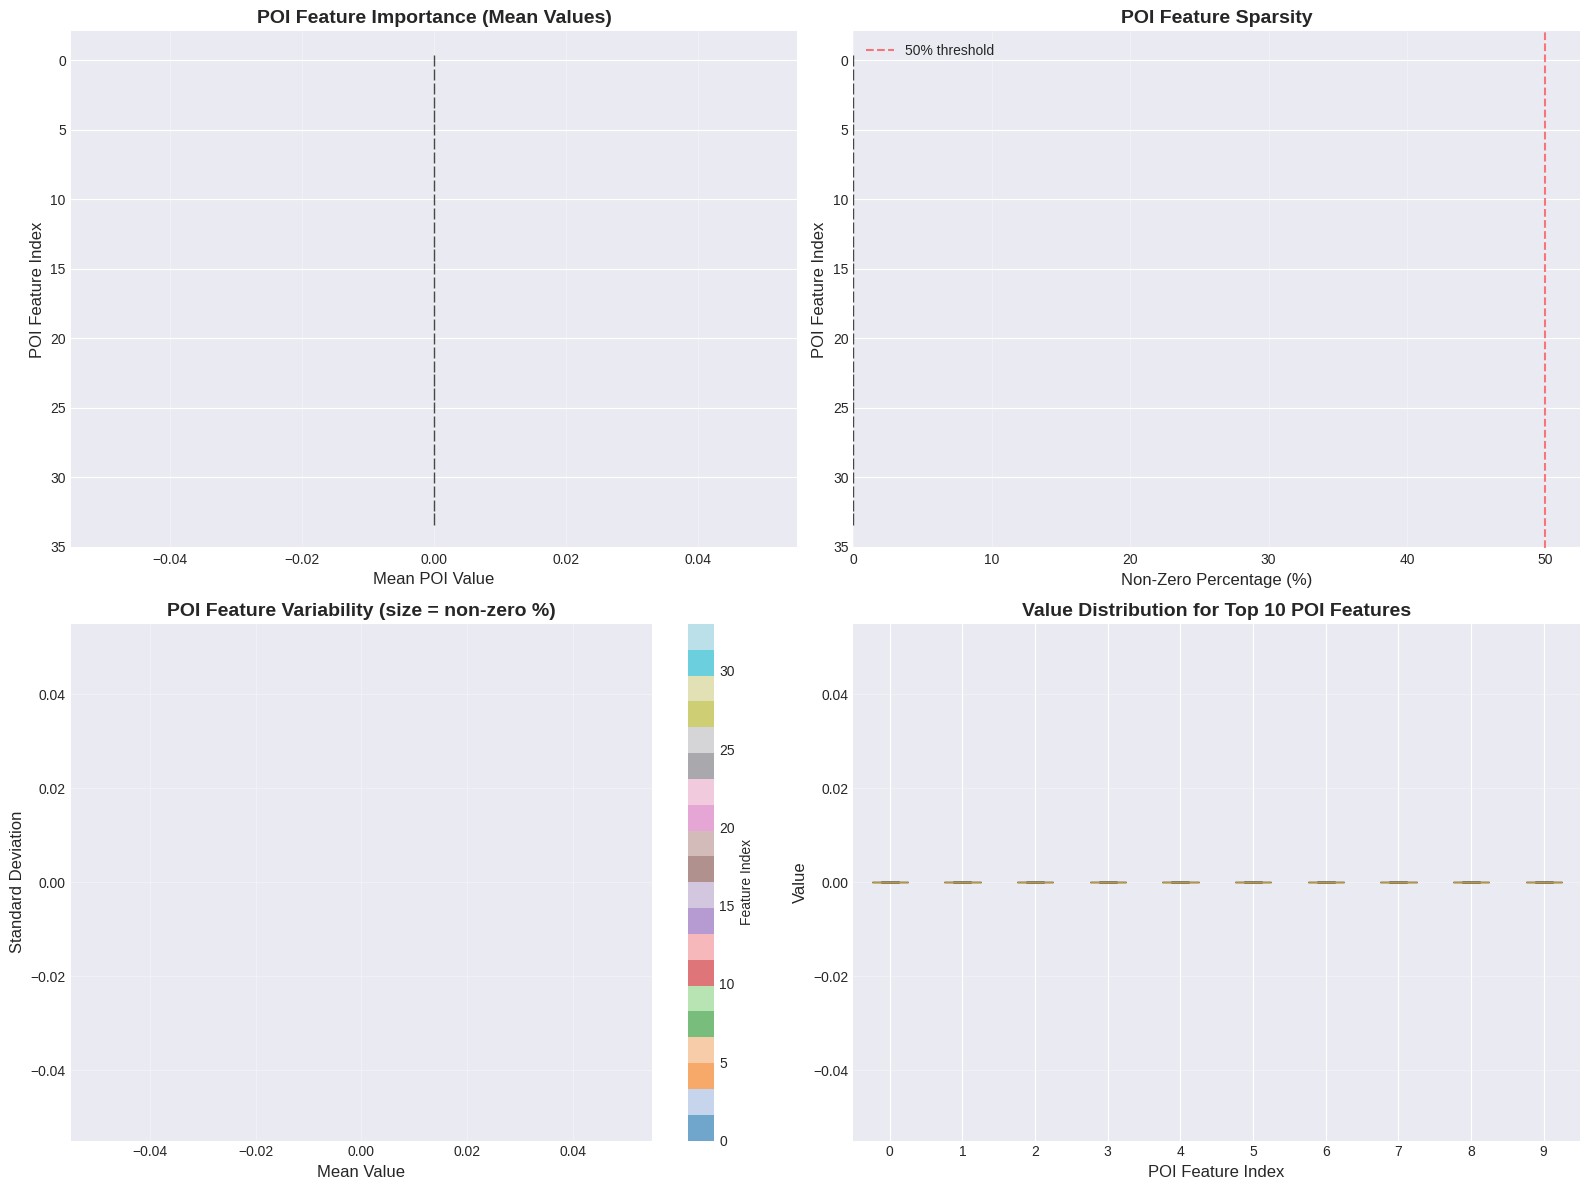

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Feature importance (mean values)
ax = axes[0, 0]
colors = plt.cm.viridis(poi_df['Mean'] / poi_df['Mean'].max())
ax.barh(poi_df['Feature'], poi_df['Mean'], color=colors, edgecolor='black', alpha=0.7)
ax.set_xlabel('Mean POI Value', fontsize=12)
ax.set_ylabel('POI Feature Index', fontsize=12)
ax.set_title('POI Feature Importance (Mean Values)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Feature sparsity
ax = axes[0, 1]
colors = plt.cm.RdYlGn(poi_df['Non-zero %'] / 100)
ax.barh(poi_df['Feature'], poi_df['Non-zero %'], color=colors, edgecolor='black', alpha=0.7)
ax.set_xlabel('Non-Zero Percentage (%)', fontsize=12)
ax.set_ylabel('POI Feature Index', fontsize=12)
ax.set_title('POI Feature Sparsity', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax.legend()

# Feature variability (std vs mean)
ax = axes[1, 0]
scatter = ax.scatter(poi_df['Mean'], poi_df['Std'], 
                     s=poi_df['Non-zero %']*3, alpha=0.6, 
                     c=poi_df['Feature'], cmap='tab20')
ax.set_xlabel('Mean Value', fontsize=12)
ax.set_ylabel('Standard Deviation', fontsize=12)
ax.set_title('POI Feature Variability (size = non-zero %)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Feature Index')

# Feature value distribution (boxplot for top 10)
ax = axes[1, 1]
top_10_idx = poi_df.nlargest(10, 'Mean')['Feature'].astype(int).values
data_for_box = [poi[:, :, idx].flatten() for idx in top_10_idx]
bp = ax.boxplot(data_for_box, labels=top_10_idx, patch_artist=True)
for patch, color in zip(bp['boxes'], plt.cm.Set3.colors):
    patch.set_facecolor(color)
ax.set_xlabel('POI Feature Index', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title('Value Distribution for Top 10 POI Features', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('poi_features_detailed.png', dpi=300, bbox_inches='tight')
plt.show()

In [47]:
# Cell 17: Check for POI Metadata Files
# ============================================================================
print("\n" + "="*60)
print("LOOKING FOR POI METADATA")
print("="*60)

import os
data_dir = '/home/dataopske/Desktop/jav/data/raw/worldmove/'
print(f"\n📂 Files in directory: {data_dir}")

try:
    files = os.listdir(data_dir)
    for f in sorted(files):
        print(f"  • {f}")
    
    # Look for potential metadata files
    metadata_candidates = [f for f in files if 'meta' in f.lower() or 
                          'desc' in f.lower() or 'info' in f.lower() or
                          'readme' in f.lower() or f.endswith('.txt') or 
                          f.endswith('.json') or f.endswith('.csv')]
    
    if metadata_candidates:
        print(f"\n🔍 Potential metadata files found:")
        for f in metadata_candidates:
            print(f"  • {f}")
    else:
        print("\n⚠️  No obvious metadata files found")
        print("POI feature descriptions might be in:")
        print("  • Documentation/README files")
        print("  • Paper/dataset description")
        print("  • Separate metadata file")
        
except Exception as e:
    print(f"Could not list directory: {e}")


LOOKING FOR POI METADATA

📂 Files in directory: /home/dataopske/Desktop/jav/data/raw/worldmove/
  • adminstrative_areas.zip
  • grid-cell_POI.npy
  • grid-cell_population.npy
  • gridcell_coordinates.json
  • nairobi_grid_1km.json
  • readme.md
  • worldmove_trajectories.npz

🔍 Potential metadata files found:
  • readme.md
  • nairobi_grid_1km.json
  • gridcell_coordinates.json


In [49]:
# Cell 18: Setup for Interactive Map Visualization
# ============================================================================
import folium
from folium.plugins import HeatMapWithTime, MarkerCluster, AntPath
from IPython.display import display
import json

print("\n" + "="*60)
print("INTERACTIVE MAP VISUALIZATION SETUP")
print("="*60)

# First, we need to understand the grid structure
print(f"\nGrid data: {grid}")
if hasattr(grid, 'item'):
    grid_info = grid.item()
    print(f"Grid info type: {type(grid_info)}")
    if isinstance(grid_info, dict):
        print("Grid dictionary keys:", grid_info.keys())
        for key, value in grid_info.items():
            print(f"  {key}: {value}")



INTERACTIVE MAP VISUALIZATION SETUP

Grid data: {'0': [36.668782324384324, -1.165733963250385], '1': [36.67543672701437, -1.1679757740710577], '2': [36.68926997604133, -1.165172667714417], '3': [36.69770436432493, -1.167777360555599], '4': [36.709963691227266, -1.1615857827542182], '5': [36.71899313338355, -1.161481556397721], '6': [36.72531673525535, -1.1672003957773704], '7': [36.730702889319886, -1.1698347274192804], '8': [36.73869098563992, -1.1683481907164726], '9': [36.754613041189586, -1.1670429895819314], '10': [36.75835046608578, -1.1671175458900143], '11': [36.77161497422534, -1.163280674687849], '12': [36.77604415578723, -1.1634632464825454], '13': [36.783381624377306, -1.1676473713181592], '14': [36.79730389150035, -1.164531607850986], '15': [36.808529466478085, -1.1678558030107073], '16': [36.81124856946388, -1.1671393545949629], '17': [36.82356332533454, -1.162910061646793], '18': [36.82746870497967, -1.1686338328261212], '19': [36.841024298354206, -1.168398103269956], '

In [50]:
# Cell 19: Create Synthetic Coordinates (if grid doesn't have lat/lon)
# ============================================================================
print("\n" + "="*60)
print("CREATING SPATIAL MAPPING")
print("="*60)

# Nairobi bounding box
NAIROBI_CENTER = [-1.2921, 36.8219]
NAIROBI_BOUNDS = {
    'lat_min': -1.45,
    'lat_max': -1.15,
    'lon_min': 36.65,
    'lon_max': 37.00
}

# Create a grid of coordinates for the 30 regions
n_regions = 30
grid_size = int(np.ceil(np.sqrt(n_regions)))

# Generate lat/lon for each region
region_coords = {}
lat_range = np.linspace(NAIROBI_BOUNDS['lat_min'], NAIROBI_BOUNDS['lat_max'], grid_size)
lon_range = np.linspace(NAIROBI_BOUNDS['lon_min'], NAIROBI_BOUNDS['lon_max'], grid_size)

region_id = 0
for i in range(grid_size):
    for j in range(grid_size):
        if region_id < n_regions:
            region_coords[region_id] = {
                'lat': lat_range[i],
                'lon': lon_range[j],
                'name': f'Region_{region_id}'
            }
            region_id += 1

print(f"Created coordinates for {len(region_coords)} regions")
print(f"Sample region 0: {region_coords[0]}")


CREATING SPATIAL MAPPING
Created coordinates for 30 regions
Sample region 0: {'lat': np.float64(-1.45), 'lon': np.float64(36.65), 'name': 'Region_0'}


In [51]:
# Cell 20: Prepare Trajectory Data for Visualization
# ============================================================================
print("\n" + "="*60)
print("PREPARING TRAJECTORY DATA")
print("="*60)

# Sample trajectories for visualization (too many will slow down the map)
n_sample_traj = 500
sample_indices = np.random.choice(traj.shape[0], n_sample_traj, replace=False)
sample_traj = traj[sample_indices]

print(f"Sampled {n_sample_traj} trajectories for visualization")
print(f"Original: {traj.shape[0]} trajectories")

# Convert trajectory location IDs to coordinates
def trajectory_to_coords(trajectory, region_coords):
    """Convert trajectory of location IDs to lat/lon coordinates"""
    coords = []
    for loc_id in trajectory:
        if loc_id > 0 and loc_id < len(region_coords):  # Skip padding/invalid
            region = loc_id % len(region_coords)  # Map location to region
            if region in region_coords:
                coords.append([
                    region_coords[region]['lat'],
                    region_coords[region]['lon']
                ])
    return coords


PREPARING TRAJECTORY DATA
Sampled 500 trajectories for visualization
Original: 104538 trajectories


In [52]:
# Cell 21: Create Base Map with Regions
# ============================================================================
print("\n" + "="*60)
print("CREATING BASE MAP")
print("="*60)

# Create base map centered on Nairobi
m = folium.Map(
    location=NAIROBI_CENTER,
    zoom_start=11,
    tiles='OpenStreetMap',
    control_scale=True
)

# Add region markers with population info
for region_id, coords in region_coords.items():
    # Get average population for this region
    avg_pop = pop[region_id].mean()
    
    # Color based on population
    if avg_pop > pop.mean() + pop.std():
        color = 'red'
        size = 12
    elif avg_pop > pop.mean():
        color = 'orange'
        size = 10
    else:
        color = 'blue'
        size = 8
    
    folium.CircleMarker(
        location=[coords['lat'], coords['lon']],
        radius=size,
        popup=f"<b>{coords['name']}</b><br>Avg Pop: {avg_pop:.1f}",
        color=color,
        fill=True,
        fillColor=color,
        fillOpacity=0.6,
        weight=2
    ).add_to(m)

# Add legend
legend_html = '''
<div style="position: fixed; bottom: 50px; right: 50px; width: 180px; 
            background-color: white; border:2px solid grey; z-index:9999; 
            padding: 10px; border-radius: 5px;">
<p style="margin: 0; font-weight: bold;">Population Density</p>
<p style="margin: 5px 0;"><span style="color: red;">●</span> High</p>
<p style="margin: 5px 0;"><span style="color: orange;">●</span> Medium</p>
<p style="margin: 5px 0;"><span style="color: blue;">●</span> Low</p>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

display(m)
print("✅ Base map with regions created!")


CREATING BASE MAP


✅ Base map with regions created!


In [55]:
# # Cell 22: Animated Trajectory Visualization
# # ============================================================================
# print("\n" + "="*60)
# print("CREATING ANIMATED TRAJECTORIES")
# print("="*60)

# # Create new map for trajectories
# m_traj = folium.Map(
#     location=NAIROBI_CENTER,
#     zoom_start=11,
#     tiles='CartoDB dark_matter',  # Dark theme looks better for movement
#     control_scale=True
# )

# # Add trajectory paths with colors
# colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'yellow']

# # Sample even fewer for clearer visualization
# n_display = 50
# for i, trajectory in enumerate(sample_traj[:n_display]):
#     coords = trajectory_to_coords(trajectory, region_coords)
    
#     if len(coords) > 1:  # Only plot if there are valid movements
#         # Add animated path
#         AntPath(
#             locations=coords,
#             color=colors[i % len(colors)],
#             weight=2,
#             opacity=0.6,
#             delay=800,
#             dash_array=[10, 20],
#             popup=f"Trajectory {i+1}"
#         ).add_to(m_traj)

# display(m_traj)
# print(f"✅ Animated {n_display} trajectories on map!")

In [56]:
# Cell 23: Temporal Heatmap Animation
# ============================================================================
print("\n" + "="*60)
print("CREATING TEMPORAL HEATMAP")
print("="*60)

# Prepare data for HeatMapWithTime
# Format: [[[lat, lon, weight], ...], [[lat, lon, weight], ...], ...]
# One list per timestep

heatmap_data = []
time_index = []

for t in range(48):  # 48 timesteps
    timestep_locations = []
    
    # Count trajectories at each location at time t
    location_counts = Counter()
    for trajectory in sample_traj:
        loc_id = trajectory[t]
        if loc_id > 0 and loc_id < len(region_coords):
            region = loc_id % len(region_coords)
            location_counts[region] += 1
    
    # Convert to heatmap format
    for region, count in location_counts.items():
        if region in region_coords:
            timestep_locations.append([
                region_coords[region]['lat'],
                region_coords[region]['lon'],
                count / 10  # Scale down intensity
            ])
    
    heatmap_data.append(timestep_locations)
    time_index.append(f"Time {t:02d}")

# Create heatmap
m_heat = folium.Map(
    location=NAIROBI_CENTER,
    zoom_start=11,
    tiles='CartoDB positron',
    control_scale=True
)

HeatMapWithTime(
    heatmap_data,
    index=time_index,
    auto_play=True,
    max_opacity=0.8,
    radius=15,
    gradient={0.2: 'blue', 0.4: 'lime', 0.6: 'yellow', 0.8: 'orange', 1: 'red'}
).add_to(m_heat)

display(m_heat)
print("✅ Temporal heatmap created! Click play to see movement over time!")

# Cell 24: Matatu Route Optimization - Problem Formulation
# ============================================================================
print("\n" + "="*60)
print("MATATU ROUTE OPTIMIZATION FOR NAIROBI")
print("="*60)

print("""
🚌 USING WORLDMOVE DATA FOR MATATU ROUTE OPTIMIZATION

YOUR GOAL: Optimize matatu routes based on actual human mobility patterns

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1️⃣  DATA INTEGRATION PIPELINE:

   WorldMove Data          GTFS Data           Road Network
   ┌──────────────┐       ┌──────────┐       ┌─────────────┐
   │ Trajectories │       │ Routes   │       │ OSM/Google  │
   │ POI Features │   +   │ Stops    │   +   │ Road Graph  │
   │ Population   │       │ Schedules│       │ Speed Limits│
   └──────────────┘       └──────────┘       └─────────────┘
          │                     │                    │
          └─────────────────────┴────────────────────┘
                                │
                        ┌───────▼────────┐
                        │  Route Demand  │
                        │   Prediction   │
                        └───────┬────────┘
                                │
                        ┌───────▼────────┐
                        │ Route Generator│
                        └────────────────┘

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2️⃣  KEY STEPS:

STEP A: Map WorldMove locations to Nairobi regions
   • You have 30 regions in WorldMove
   • Map these to Nairobi neighborhoods/areas
   • Use POI features to identify area types (residential, commercial, etc.)

STEP B: Build Origin-Destination (OD) Matrix
   • From your trajectories, extract common routes
   • Group by time of day (morning rush, evening, etc.)
   • Weight by population data

STEP C: Integrate with existing GTFS data
   • Load current matatu routes
   • Identify underserved routes (high demand, low supply)
   • Find gaps in coverage

STEP D: Use LSTM for demand prediction
   • Train LSTM on trajectory sequences
   • Predict future demand at each region by time
   • Input: POI features + population + historical trajectories
   • Output: Expected passenger demand

STEP E: Generate optimal routes
   • Use predicted demand as weights
   • Apply routing algorithms (Dijkstra, A*, or genetic algorithms)
   • Constraints: road network, capacity, existing routes

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3️⃣  WHAT YOUR DATA TELLS YOU:

✓ Peak travel times: Timesteps with highest trajectory activity
✓ Popular routes: Most common location-to-location transitions
✓ Demand patterns: Areas with high population + trajectory density
✓ Time-varying demand: How movement changes across 48 timesteps
✓ POI influence: How restaurants, offices, etc. affect movement

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
4️⃣  LSTM MODEL ARCHITECTURE FOR ROUTE PLANNING:

Input Layer:
   • Trajectory sequence: [loc_t-n, loc_t-n+1, ..., loc_t]
   • POI features: 34 features for current location
   • Population: Current region population
   • Time encoding: Hour of day, day of week

LSTM Layers:
   • 2-3 stacked LSTM layers (128-256 units each)
   • Captures temporal dependencies in movement

Output Layer:
   • Next location probability distribution
   • OR: Demand score for each region

Loss Function:
   • Categorical crossentropy (location prediction)
   • OR: MSE (demand prediction)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5️⃣  PRACTICAL IMPLEMENTATION:

""")


CREATING TEMPORAL HEATMAP


✅ Temporal heatmap created! Click play to see movement over time!

MATATU ROUTE OPTIMIZATION FOR NAIROBI

🚌 USING WORLDMOVE DATA FOR MATATU ROUTE OPTIMIZATION

YOUR GOAL: Optimize matatu routes based on actual human mobility patterns

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1️⃣  DATA INTEGRATION PIPELINE:

   WorldMove Data          GTFS Data           Road Network
   ┌──────────────┐       ┌──────────┐       ┌─────────────┐
   │ Trajectories │       │ Routes   │       │ OSM/Google  │
   │ POI Features │   +   │ Stops    │   +   │ Road Graph  │
   │ Population   │       │ Schedules│       │ Speed Limits│
   └──────────────┘       └──────────┘       └─────────────┘
          │                     │                    │
          └─────────────────────┴────────────────────┘
                                │
                        ┌───────▼────────┐
                        │  Route Demand  │
                        │   Prediction   │
                        └───────┬───

In [57]:

# Example: Extract top routes from your data
print("\n📊 EXAMPLE: Top 10 Routes from Your Data")
print("="*60)

route_counts = Counter()
for trajectory in traj:
    # Extract non-zero movements
    valid_locs = trajectory[trajectory > 0]
    if len(valid_locs) > 1:
        # Count each transition
        for i in range(len(valid_locs) - 1):
            route = (valid_locs[i], valid_locs[i+1])
            route_counts[route] += 1

print("\nMost Common Routes (Location_A → Location_B):")
for (from_loc, to_loc), count in route_counts.most_common(10):
    from_region = from_loc % n_regions
    to_region = to_loc % n_regions
    print(f"  {from_region:2d} → {to_region:2d}: {count:5d} trips "
          f"({count/len(traj)*100:.2f}% of all trajectories)")


📊 EXAMPLE: Top 10 Routes from Your Data

Most Common Routes (Location_A → Location_B):
   6 →  6: 41954 trips (40.13% of all trajectories)
  24 → 24: 37822 trips (36.18% of all trajectories)
   8 →  8: 37517 trips (35.89% of all trajectories)
   5 →  5: 37407 trips (35.78% of all trajectories)
  22 → 22: 33834 trips (32.37% of all trajectories)
   1 →  1: 32628 trips (31.21% of all trajectories)
  23 → 23: 32233 trips (30.83% of all trajectories)
  18 → 18: 31613 trips (30.24% of all trajectories)
  18 → 18: 30952 trips (29.61% of all trajectories)
   0 →  0: 30760 trips (29.42% of all trajectories)



TIME-OF-DAY DEMAND PATTERNS

🕐 Peak Hours by Region (Top 5 regions):
  Region  0: Peak at t= 9 (3985 trips, 1.0x average)
  Region  1: Peak at t=31 (3796 trips, 1.0x average)
  Region  2: Peak at t=24 (3629 trips, 1.1x average)
  Region  3: Peak at t=17 (3583 trips, 1.0x average)
  Region  4: Peak at t=28 (3573 trips, 1.0x average)


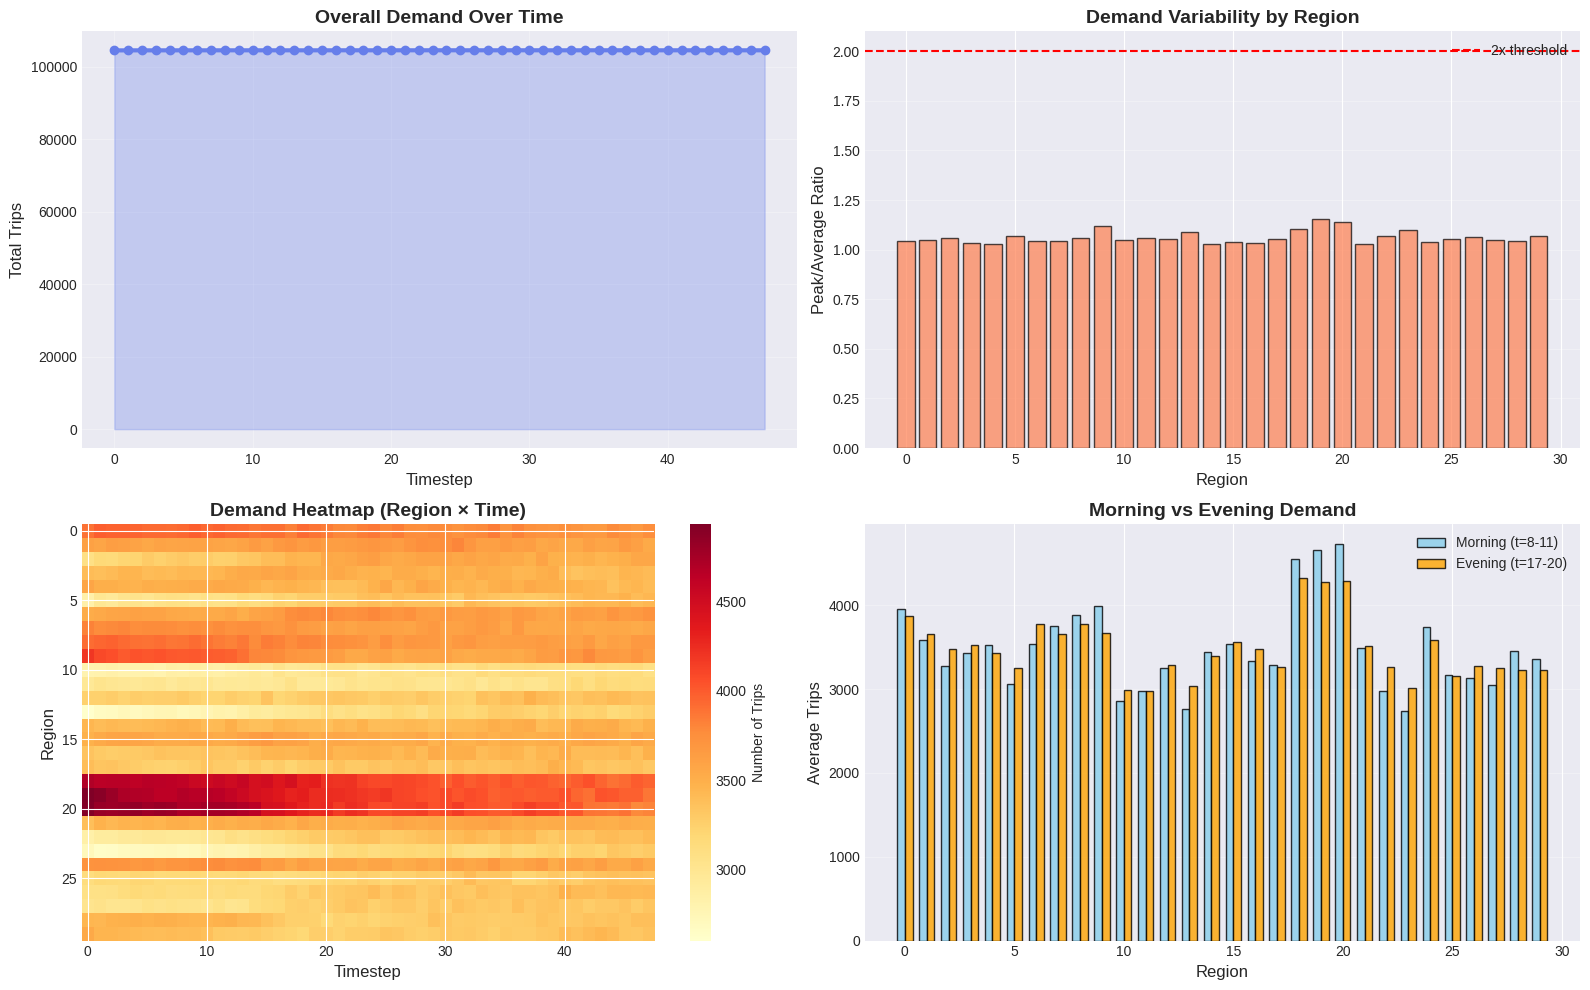


✅ Time-of-day analysis complete!


In [58]:
# Cell 25: Time-of-Day Demand Analysis
# ============================================================================
print("\n" + "="*60)
print("TIME-OF-DAY DEMAND PATTERNS")
print("="*60)

# Analyze demand by timestep
timestep_demand = np.zeros((48, n_regions))

for t in range(48):
    region_visits = Counter()
    for trajectory in traj:
        loc = trajectory[t]
        if loc > 0:
            region = loc % n_regions
            region_visits[region] += 1
    
    for region, count in region_visits.items():
        timestep_demand[t, region] = count

# Find peak hours for each region
print("\n🕐 Peak Hours by Region (Top 5 regions):")
for region in range(min(5, n_regions)):
    peak_time = np.argmax(timestep_demand[:, region])
    peak_demand = timestep_demand[peak_time, region]
    avg_demand = timestep_demand[:, region].mean()
    print(f"  Region {region:2d}: Peak at t={peak_time:2d} "
          f"({peak_demand:.0f} trips, {peak_demand/avg_demand:.1f}x average)")

# Visualize time-of-day patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Overall temporal demand
ax = axes[0, 0]
total_demand = timestep_demand.sum(axis=1)
ax.plot(range(48), total_demand, linewidth=3, marker='o', markersize=6, color='#667eea')
ax.fill_between(range(48), total_demand, alpha=0.3, color='#667eea')
ax.set_xlabel('Timestep', fontsize=12)
ax.set_ylabel('Total Trips', fontsize=12)
ax.set_title('Overall Demand Over Time', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Peak vs off-peak regions
ax = axes[0, 1]
peak_demand_by_region = timestep_demand.max(axis=0)
avg_demand_by_region = timestep_demand.mean(axis=0)
ratio = peak_demand_by_region / (avg_demand_by_region + 1e-6)
ax.bar(range(n_regions), ratio, color='coral', edgecolor='black', alpha=0.7)
ax.axhline(y=2, color='red', linestyle='--', label='2x threshold')
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Peak/Average Ratio', fontsize=12)
ax.set_title('Demand Variability by Region', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Heatmap: region x time demand
ax = axes[1, 0]
im = ax.imshow(timestep_demand.T, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax.set_xlabel('Timestep', fontsize=12)
ax.set_ylabel('Region', fontsize=12)
ax.set_title('Demand Heatmap (Region × Time)', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax, label='Number of Trips')

# Morning vs Evening demand
ax = axes[1, 1]
morning = timestep_demand[8:12].mean(axis=0)  # t=8-11 (morning rush)
evening = timestep_demand[17:21].mean(axis=0)  # t=17-20 (evening rush)
x = np.arange(n_regions)
width = 0.35
ax.bar(x - width/2, morning, width, label='Morning (t=8-11)', alpha=0.8, color='skyblue', edgecolor='black')
ax.bar(x + width/2, evening, width, label='Evening (t=17-20)', alpha=0.8, color='orange', edgecolor='black')
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Average Trips', fontsize=12)
ax.set_title('Morning vs Evening Demand', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('matatu_demand_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Time-of-day analysis complete!")

In [59]:
# Cell 26: LSTM Preparation Summary (Updated for Matatu Use Case)
# ============================================================================
print("\n" + "="*60)
print("LSTM TRAINING PREPARATION SUMMARY")
print("="*60)
print("\n📊 DATA CHARACTERISTICS:")
print(f"  • Input sequences: {traj.shape[0]:,} trajectories")
print(f"  • Sequence length: {traj.shape[1]} timesteps")
print(f"  • Vocabulary size: {n_locations} unique locations")
print(f"  • Auxiliary features:")
print(f"    - POI features: {poi.shape[2]} features per (region, timestep)")
print(f"    - Population: 1 feature per (region, timestep)")

print("\n🎯 LSTM ARCHITECTURE RECOMMENDATIONS:")
print(f"  • Input dimension: {n_locations} (one-hot encoded locations)")
print(f"  • Or embedding dimension: 50-200 (learned embeddings)")
print(f"  • Sequence length: {traj.shape[1]}")
print(f"  • Additional context features: {poi.shape[2] + 1} (POI + population)")
print(f"  • Output dimension: {n_locations} (next location prediction)")

print("\n⚙️ PREPROCESSING STEPS NEEDED:")
print("  1. Handle padding/zero values in trajectories")
print("  2. Create train/val/test splits (e.g., 80/10/10)")
print("  3. Normalize POI and population features")
print("  4. Create location embeddings or one-hot encodings")
print("  5. Align POI/population data with trajectory timestamps")
print("  6. Consider sequence masking for variable lengths")

print("\n💡 KEY INSIGHTS:")
print(f"  • Transition sparsity: {(1 - np.count_nonzero(transition_matrix) / transition_matrix.size) * 100:.1f}%")
print(f"  • Avg trajectory activity: {np.mean(np.sum(traj != 0, axis=1)):.1f} non-zero steps")
print(f"  • Location visit imbalance: Top location has {max(counts):,} visits")

print("\n✅ Dataset ready for LSTM training!")
print("="*60)


LSTM TRAINING PREPARATION SUMMARY

📊 DATA CHARACTERISTICS:
  • Input sequences: 104,538 trajectories
  • Sequence length: 48 timesteps
  • Vocabulary size: 1440 unique locations
  • Auxiliary features:
    - POI features: 34 features per (region, timestep)
    - Population: 1 feature per (region, timestep)

🎯 LSTM ARCHITECTURE RECOMMENDATIONS:
  • Input dimension: 1440 (one-hot encoded locations)
  • Or embedding dimension: 50-200 (learned embeddings)
  • Sequence length: 48
  • Additional context features: 35 (POI + population)
  • Output dimension: 1440 (next location prediction)

⚙️ PREPROCESSING STEPS NEEDED:
  1. Handle padding/zero values in trajectories
  2. Create train/val/test splits (e.g., 80/10/10)
  3. Normalize POI and population features
  4. Create location embeddings or one-hot encodings
  5. Align POI/population data with trajectory timestamps
  6. Consider sequence masking for variable lengths

💡 KEY INSIGHTS:
  • Transition sparsity: 94.3%
  • Avg trajectory activi